# Nino3.4 SST Skill (correlation & nRMSE) & DJF Time Series

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import dask
from dask.distributed import wait

from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats

from esp_lab.utils import spatial_utils as spatial
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mov_utils as mov

from esp_lab.utils.dask_utils import (
    DaskConfig,
    get_cluster_client,
    close_cluster,
)

from esp_lab.diagnostics import S2DDiagnostics, S2DConfig

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


In [2]:
print("xarray:", xr.__version__)
print("dask:", dask.__version__)

xarray: 2026.4.0
dask: 2026.3.0


In [3]:
# -----------------------------
# Dask setup
# -----------------------------
machine_env = os.environ.get("CLUSTER_TYPE", "local")

dask_cfg = DaskConfig(
    cluster_type=machine_env,   # "local", "slurm", "casper_pbs", or "none"
    workers=30,
    cores=4,
    memory="16GB",
    walltime="02:00:00",
    queue=None,
    project=None,
)

cluster, client = get_cluster_client(dask_cfg)

print(client)

<Client: 'tcp://127.0.0.1:43145' processes=30 threads=30, memory=502.97 GiB>


2026-06-19 13:51:01,697 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('sub-51174887d2debb139ca6455d641aaeed', 1, 0, 9, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('sub-51174887d2debb139ca6455d641aaeed', 1, 0, 9, 0, 0)->('concatenate-getitem-rechunk-merge-rechunk-split-sub-51174887d2debb139ca6455d641aaeed', 1, 0, 9, 0, 0))
new run_spec: <Task ('sub-51174887d2debb139ca6455d641aaeed', 1, 0, 9, 0, 0) _execute_subgraph(...)>
old dependencies: {('concatenate-getitem-rechunk-merge-rechunk-split-sub-51174887d2debb139ca6455d641aaeed', 1, 0, 9, 0, 0)}
new dependencies: frozenset({('concat

### Read in monthly SST field using I/O functions; Convert to seasonal mean

In [4]:
%%time
# -----------------------------
# Diagnostics configuration
# -----------------------------
field = "TS"

case_nens = 10
case_nlead = 24

data_dir = "/global/cfs/cdirs/e3sm/S2S2D/post_process"
case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"
outdir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE'

force_rewrite = True

members = [f"EN{i:02d}" for i in range(case_nens)]

years = 1980
yeare = 2018
yexcl = None

# Drift / skill climatology years
climy0 = 1980
climy1 = 2010

init_months = [5, 11]
init_years = {
    5: [y for y in np.arange(years, yeare + 1) if y != yexcl],
    11: [y for y in np.arange(years, yeare + 1) if y != yexcl],
}

region = [-170.0, -120.0, -5.0, 5.0]
region_name = "Nino3.4"

realm = "atm"
grid = "180x360_aave"
freq = "monthly"
ts_split = "2yr"
engine = "netcdf4"

# Keep open-time chunking light/safe
chunks = {}

# Use this later after data are combined, before heavy operations
mchunk = {
    "Y": 3,
    "L": 24,
    "M": 2,
    "lat": 90,
    "lon": 180,
}

require_all_members = True
verify_field_name = True
verify_coverage = True

persist_intermediate = True
load_regional_series = True
convert_ts_to_degC = True

cfg = S2DConfig(
    field=field,
    data_dir=data_dir,
    case_prefix=case_prefix,
    members=members,
    nlead=case_nlead,
    init_months=init_months,
    init_years=init_years,
    region=region,
    region_name=region_name,
    climy0=climy0,
    climy1=climy1,
    outdir=outdir,
    force_rewrite=force_rewrite,
    realm=realm,
    grid=grid,
    freq=freq,
    ts_split=ts_split,
    engine=engine,
    chunks=chunks,
    require_all_members=require_all_members,
    verify_field_name=verify_field_name,
    verify_coverage=verify_coverage,
    persist_intermediate=persist_intermediate,
    load_regional_series=load_regional_series,
    convert_ts_to_degC=convert_ts_to_degC,
)

print(cfg)

S2DConfig(field='TS', case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL', data_dir='/global/cfs/cdirs/e3sm/S2S2D/post_process', members=['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09'], nlead=24, init_months=[5, 11], init_years={5: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)], 11: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(198

In [5]:
%%time
# -----------------------------
# Create diagnostics object
# -----------------------------
diag = S2DDiagnostics(
    cfg=cfg,
    data_access=data_access,
    obs_access=obs_access,
    stats=stats,
    spatial=spatial,
    cal=cal,
)

# -----------------------------
# Run model diagnostics
# -----------------------------
results = diag.run()

# Quick inspection
for m in cfg.init_months:
    print(f"\n=== Init month: {m} ===")
    print(results[m]["mon"])
    print(results[m]["seas"])
    print(results[m]["time_mon"])
    print(results[m]["time_seas"])


=== Init month: 5 ===
<xarray.DataArray 'TS' (Y: 39, L: 24, M: 10)> Size: 75kB
array([[[28.61984625, 28.57773985, 28.56677346, ..., 28.53963168,
         28.53004571, 28.59654321],
        [28.40390416, 28.13090699, 28.22561052, ..., 28.31239338,
         28.16371275, 28.16621323],
        [27.38765117, 26.78736247, 27.36016064, ..., 27.46266479,
         27.48299143, 26.87114052],
        ...,
        [23.94711044, 24.94103603, 24.68270855, ..., 23.61329548,
         23.86973372, 26.4633312 ],
        [24.6743342 , 26.00698145, 25.6699161 , ..., 24.71458599,
         24.80896996, 26.82831912],
        [25.77967764, 26.81408663, 26.49255821, ..., 25.77048273,
         25.77116582, 27.31397247]],

       [[27.52844675, 27.58539813, 27.61903768, ..., 27.63669367,
         27.55379488, 27.55252727],
        [26.64172379, 26.55592611, 26.79123001, ..., 26.87700539,
         26.7705433 , 26.65428401],
        [25.232667  , 25.14766472, 25.13491428, ..., 25.38648718,
         25.34230873, 2

<xarray.DataArray 'sftlf' (lat: 180, lon: 360)> Size: 65kB
dask.array<xarray-<this-array>, shape=(180, 360), dtype=int8, chunksize=(90, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    long_name:  land fraction mask
    units:      1


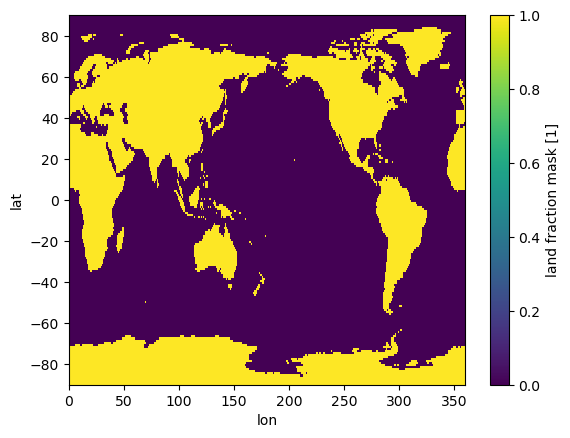

In [6]:
# -----------------------------
# Save fixed landmask from one init month
# -----------------------------
outdir = cfg.outdir
fixed_dir = os.path.join(outdir, "fixed")
os.makedirs(fixed_dir, exist_ok=True)

landmask_file = os.path.join(fixed_dir, "sftlf.E3SM.nc")

if not os.path.exists(landmask_file) or cfg.force_rewrite:
    if os.path.exists(landmask_file):
        os.remove(landmask_file)

    _first_m = cfg.init_months[0]

    landmask = results[_first_m]["landmask"]

    # ensure 0/1 integer mask
    landmask = landmask.astype("int8")
    landmask.name = "sftlf"
    landmask.attrs["long_name"] = "land fraction mask"
    landmask.attrs["units"] = "1"

    # optional: ensure consistent chunking before write
    landmask = landmask.chunk({"lat": 90, "lon": 180})

    landmask.to_netcdf(landmask_file)
else:
    landmask = xr.open_dataarray(landmask_file)

# Quick check
landmask.plot()
print(landmask)

In [7]:
%%time
# -----------------------------
# Save regional monthly/seasonal model indices
# -----------------------------
os.makedirs(outdir, exist_ok=True)

index_encoding = {
    "sst": {
        "zlib": True,
        "complevel": 1,
    }
}

for m in cfg.init_months:
    # seasonal
    outfile_seas = os.path.join(
        outdir,
        f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{cfg.region_name}SST_seas.nc"
    )

    if not os.path.exists(outfile_seas) or cfg.force_rewrite:
        if os.path.exists(outfile_seas):
            os.remove(outfile_seas)

        ds_seas = results[m]["seas"].rename("sst").to_dataset()
        ds_seas["time"] = results[m]["time_seas"].load()
        ds_seas["sst"].attrs.update({
            "long_name": f"{cfg.region_name} regional mean SST",
            "region": cfg.region_name,
            "lonlat": str(list(cfg.region)),
            "units": "degC",
        })

        ds_seas.to_netcdf(outfile_seas, encoding=index_encoding)

    # monthly
    outfile_mon = os.path.join(
        outdir,
        f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{cfg.region_name}SST_mon.nc"
    )

    if not os.path.exists(outfile_mon) or cfg.force_rewrite:
        if os.path.exists(outfile_mon):
            os.remove(outfile_mon)

        ds_mon = results[m]["mon"].rename("sst").to_dataset()
        ds_mon["time"] = results[m]["time_mon"].load()
        ds_mon["sst"].attrs.update({
            "long_name": f"{cfg.region_name} regional mean SST",
            "region": cfg.region_name,
            "lonlat": str(list(cfg.region)),
            "units": "degC",
        })

        ds_mon.to_netcdf(outfile_mon, encoding=index_encoding)

CPU times: user 163 ms, sys: 116 ms, total: 279 ms
Wall time: 400 ms


In [8]:
# -----------------------------
# Verify saved model regional series (optional sanity check)
# -----------------------------
for m in cfg.init_months:
    for freq_tag in ["seas", "mon"]:
        outfile = os.path.join(
            outdir,
            f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{cfg.region_name}SST_{freq_tag}.nc"
        )

        if not os.path.exists(outfile):
            print(f"[WARNING] Missing file: {outfile}")
            continue

        with xr.open_dataset(outfile) as ds:
            print(f"\nmonth={m}, freq={freq_tag}")
            print(ds)

            # quick sanity checks
            if "sst" in ds:
                print(
                    "  sst min/max:",
                    float(ds["sst"].min()),
                    float(ds["sst"].max())
                )
                print("  units:", ds["sst"].attrs.get("units", "N/A"))
                


month=5, freq=seas
<xarray.Dataset> Size: 29kB
Dimensions:  (Y: 39, L: 8, M: 10)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 25kB ...
    time     (Y, L) object 2kB ...
  sst min/max: 19.465014364430317 29.67703283721191
  units: degC

month=5, freq=mon
<xarray.Dataset> Size: 84kB
Dimensions:  (Y: 39, L: 24, M: 10)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 75kB ...
    time     (Y, L) object 7kB ...
  sst min/max: 19.38335955298106 29.79373041790469
  units: degC

month=11, freq=seas
<xarray.Dataset> Size: 29kB
Dimensions:  (Y: 39, L: 

In [9]:
%%time
# -----------------------------
# Load observations
# -----------------------------
obs_dir = "/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series"
obs_product = "HadISST2"
obs_var = "sst"
obs_yrs = 1869
obs_yre = 2022

obs_chunk = {
    "time": 120,
    "lat": 90,
    "lon": 180,
}

obs_hadisst = obs_access.get_monthly_data(
    obs_dir=obs_dir,
    field=field,
    field_map={field: obs_var},
    product=obs_product,
    start_year=obs_yrs,
    end_year=obs_yre,
    chunks=obs_chunk,
    verbose=True,
)

obs_hadisst = obs_hadisst.sel(time=slice(str(obs_yrs), str(obs_yre)))

obs_hadisst[obs_var] = xr.where(
    obs_hadisst[obs_var] < -2.0,
    -1.8,
    obs_hadisst[obs_var],
)

obs_hadisst = obs_hadisst.chunk(obs_chunk)

print(obs_hadisst)

[OBS] Mapping field 'TS' -> 'sst'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/HadISST2/sst_186901_202212.nc


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/data_access_obs.py:819: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks=chunks, decode_times=decode_times)
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/data_access_obs.py:819: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks=chunks, decode_times=decode_times)


<xarray.Dataset> Size: 479MB
Dimensions:  (time: 1848, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 15kB 1869-01-15 00:00:00 ... 2022-12-15 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    sst      (time, lat, lon) float32 479MB dask.array<chunksize=(120, 90, 180), meta=np.ndarray>
Attributes: (12/39)
    Conventions:                CF-1.7 CMIP-6.2
    activity_id:                input4MIPs
    comment:                    Based on Hurrell SST/sea ice consistency crit...
    contact:                    PCMDI (pcmdi-cmip@llnl.gov)
    creation_date:              2024-02-15T21:10:18Z
    data_specs_version:         01.00.33
    ...                         ...
    external_variables:         areacello
    NCO:                        netCDF Operators version 5.2.4 (Homepage = ht...
    history_of_appended_files:  Thu Feb 15 13:24:13 2024: A

In [10]:
%%time
# -----------------------------
# Compute obs seasonal means
# -----------------------------
obs_hadisst_seas = obs_access.mon_to_seas_obs(
    obs_hadisst,
    var=obs_var,
    field_map={field: obs_var},
)

# Important: rechunk after rolling/seasonal aggregation
obs_hadisst_seas = obs_hadisst_seas.chunk(obs_chunk)

print(obs_hadisst_seas)

<xarray.DataArray 'TS' (time: 1846, lat: 180, lon: 360)> Size: 478MB
dask.array<rechunk-merge, shape=(1846, 180, 360), dtype=float32, chunksize=(120, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 15kB 1869-02-15 00:00:00 ... 2022-11-15 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
CPU times: user 371 ms, sys: 130 ms, total: 501 ms
Wall time: 798 ms


<xarray.DataArray 'sftlf' (lat: 180, lon: 360)> Size: 65kB
dask.array<xarray-<this-array>, shape=(180, 360), dtype=int8, chunksize=(90, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    long_name:  land fraction mask
    units:      1


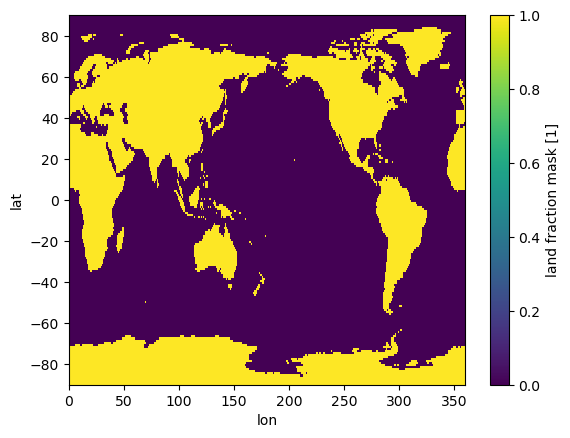

In [11]:
# -----------------------------
# Build / save obs landmask
# -----------------------------
obs_mask_file = os.path.join(fixed_dir, f"sftlf.{obs_product}.nc")

lat_key = "lat"
lon_key = "lon"
mask_var = "sftlf"
mask_type = "int8"
mask_name = "land fraction mask"
mask_unit = "1"
mask_chunk = {lat_key: 90, lon_key: 180} 

if not os.path.exists(obs_mask_file) or cfg.force_rewrite:
    if os.path.exists(obs_mask_file):
        os.remove(obs_mask_file)

    # Robust variable selection
    if isinstance(obs_hadisst_seas, xr.DataArray):
        da_obs_mask = obs_hadisst_seas
    else:
        if obs_var in obs_hadisst_seas:
            da_obs_mask = obs_hadisst_seas[obs_var]
        elif field in obs_hadisst_seas:
            da_obs_mask = obs_hadisst_seas[field]
        else:
            raise KeyError("Cannot find SST variable in obs dataset")

    # Build mask
    landmasko = spatial.create_land_sea_mask(
        da_obs_mask,
        lat_key=lat_key,
        lon_key=lon_key,
    )

    # Ensure clean binary mask
    landmasko = landmasko.astype(mask_type)
    landmasko.name = mask_var
    landmasko.attrs["long_name"] = mask_name
    landmasko.attrs["units"] = mask_unit

    # Optional: consistent chunking
    landmasko = landmasko.chunk(mask_chunk)

    landmasko.to_netcdf(obs_mask_file)

else:
    landmasko = xr.open_dataarray(obs_mask_file, chunks=mask_chunk)
    
# Quick check
landmasko.plot()
print(landmasko)

In [12]:
%%time
# -----------------------------
# Compute obs regional monthly/seasonal SST index
# -----------------------------
lat_name = "lat"
lon_name = "lon"

oceanmasko = (~landmasko.astype(bool)).chunk(mask_chunk)

# Standardize obs objects to DataArray
if isinstance(obs_hadisst, xr.Dataset):
    obs_mon_da = obs_hadisst[field] if field in obs_hadisst.data_vars else obs_hadisst[obs_var]
else:
    obs_mon_da = obs_hadisst

if isinstance(obs_hadisst_seas, xr.Dataset):
    obs_seas_da = obs_hadisst_seas[field] if field in obs_hadisst_seas.data_vars else obs_hadisst_seas[obs_var]
else:
    obs_seas_da = obs_hadisst_seas

obs_mon_da = obs_mon_da.rename(field)
obs_seas_da = obs_seas_da.rename(field)

obs_reg_ocean_area_mon = obs_access.obs_regional_weights(
    obs_mon_da,
    cfg.region,
    lat_name=lat_name,
    lon_name=lon_name,
    mask=oceanmasko,
)

obs_reg_ocean_area_seas = obs_access.obs_regional_weights(
    obs_seas_da,
    cfg.region,
    lat_name=lat_name,
    lon_name=lon_name,
    mask=oceanmasko,
)

obs_seas = (
    obs_seas_da
    .weighted(obs_reg_ocean_area_seas)
    .mean((lat_name, lon_name))
    .load()
)

obs_mon = (
    obs_mon_da
    .weighted(obs_reg_ocean_area_mon)
    .mean((lat_name, lon_name))
    .load()
)

print(obs_seas)
print(obs_mon)


<xarray.DataArray 'TS' (time: 1846)> Size: 15kB
array([25.08537803, 25.18409306, 25.72588   , ..., 25.74592395,
       25.75517941, 25.79297127], shape=(1846,))
Coordinates:
  * time     (time) object 15kB 1869-02-15 00:00:00 ... 2022-11-15 00:00:00
<xarray.DataArray 'TS' (time: 1848)> Size: 15kB
array([25.52417765, 24.20695444, 25.52500193, ..., 25.76622585,
       25.85643932, 25.75624646], shape=(1848,))
Coordinates:
  * time     (time) object 15kB 1869-01-15 00:00:00 ... 2022-12-15 00:00:00
CPU times: user 949 ms, sys: 367 ms, total: 1.32 s
Wall time: 1.74 s


In [13]:
%%time
# -----------------------------
# Drift removal using diagnostics class
# -----------------------------
results_dd = diag.remove_drift_for_results(results)

regsst_dd = {}
regsst_drift = {}
seas_regsst_dd = {}
seas_regsst_drift = {}

for m in cfg.init_months:
    regsst_dd[m] = results_dd[m]["mon_dd"]
    regsst_drift[m] = results_dd[m]["mon_drift"]

    seas_regsst_dd[m] = results_dd[m]["seas_dd"]
    seas_regsst_drift[m] = results_dd[m]["seas_drift"]

# convenient access
e3smle05_regsst_dd = regsst_dd.get(5)
e3smle11_regsst_dd = regsst_dd.get(11)

e3smle05_seas_regsst_dd = seas_regsst_dd.get(5)
e3smle11_seas_regsst_dd = seas_regsst_dd.get(11)

CPU times: user 12.7 ms, sys: 160 μs, total: 12.8 ms
Wall time: 11.6 ms


In [14]:
%%time
# -----------------------------
# Skill computation using diagnostics class
# -----------------------------
results_skill = diag.compute_skill_for_results(
    results_dd,
    obs_mon=obs_mon,
    obs_seas=obs_seas,
    seasonal_nlead=cfg.seasonal_nlead,
)

skill_mon = {}
skill_seas = {}

for m in cfg.init_months:
    skill_mon[m] = results_skill[m]["skill_mon"]
    skill_seas[m] = results_skill[m]["skill_seas"]

# convenient access
e3smle05_skill = skill_mon.get(5)
e3smle11_skill = skill_mon.get(11)

e3smle05_seas_skill = skill_seas.get(5)
e3smle11_seas_skill = skill_seas.get(11)

CPU times: user 1.51 s, sys: 394 ms, total: 1.9 s
Wall time: 1.77 s


In [15]:
# -----------------------------
# Combine skill arrays for plotting
# -----------------------------
startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

skill_list = [skill_mon[m] for m in cfg.init_months]
seas_skill_list = [skill_seas[m] for m in cfg.init_months]

e3smle_skill = xr.concat(skill_list, dim=startmonth)
e3smle_seas_skill = xr.concat(seas_skill_list, dim=startmonth)

print(e3smle_skill)
print(e3smle_seas_skill)

<xarray.Dataset> Size: 4kB
Dimensions:     (startmonth: 2, L: 24)
Coordinates:
  * startmonth  (startmonth) int64 16B 5 11
  * L           (L) int64 192B 1 2 3 4 5 6 7 8 9 ... 16 17 18 19 20 21 22 23 24
Data variables:
    corr        (startmonth, L) float64 384B 0.9296 0.8917 ... 0.1807 0.1432
    pval        (startmonth, L) float64 384B 3.484e-17 2.653e-14 ... 0.3845
    rmse        (startmonth, L) float64 384B 0.3927 0.7028 ... 1.097 1.095
    msss        (startmonth, L) float64 384B 0.8458 0.506 ... -0.2045 -0.1998
    rpc         (startmonth, L) float64 384B 0.9309 0.9116 ... 0.3101 0.258
    sig_obs     (startmonth, L) float64 384B 0.614 0.6158 ... 0.8625 1.054
    sig_sig     (startmonth, L) float64 384B 0.6542 0.8803 1.1 ... 0.5759 0.6456
    sig_tot     (startmonth, L) float64 384B 0.6551 0.8999 ... 0.9883 1.163
    s2t         (startmonth, L) float64 384B 0.9986 0.9782 ... 0.5827 0.5549
<xarray.Dataset> Size: 1kB
Dimensions:     (startmonth: 2, L: 8)
Coordinates:
  * startmon

### CESM-SMYLE benchmark comparison

This section follows the CESM-SMYLE benchmark workflow used in the skill-map notebooks, but applies it to the Niño3.4 regional SST index:

- load preprocessed CESM-SMYLE seasonal benchmark fields,
- compute the same Niño3.4 ocean regional mean,
- remove lead-dependent drift using the same climatology window,
- compute seasonal ACC/nRMSE skill against HadISST,
- make the benchmark available for the skill and DJF time-series plots.

**Significance interpretation:** filled ACC markers in the skill plot use each model's
correlation p-value against the null hypothesis of zero correlation. They do not test
whether E3SMLE is significantly better than CESM-SMYLE. A between-model superiority
claim would require the matched-ensemble resampling used in the map notebooks, applied
separately to ACC and nRMSE on the common verification years.


In [16]:
%%time
# -----------------------------
# CESM-SMYLE benchmark regional index and skill comparison
# -----------------------------
from esp_lab import data_access_cesm_smyle as smyle_access

SMYLE_BENCHMARK_DIR = "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE"
smyle_outdir = os.path.join(SMYLE_BENCHMARK_DIR, cfg.region_name)
os.makedirs(smyle_outdir, exist_ok=True)

smyle_nens = 20
smyle_nlead = case_nlead
smyle_force_rewrite = cfg.force_rewrite

smyle_chunks = {
    "Y": 3,
    "L": -1,
    "M": 2,
    "lat": 96,
    "lon": 144,
}

smyle_index_encoding = {
    "sst": {
        "zlib": True,
        "complevel": 1,
    }
}

def _safe_to_netcdf(ds, path, encoding=None):
    """Write NetCDF through a temporary file to avoid corrupted cache files."""
    tmp_path = path + ".tmp"
    if os.path.exists(tmp_path):
        os.remove(tmp_path)
    ds.to_netcdf(tmp_path, encoding=encoding)
    os.replace(tmp_path, path)


def _convert_smyle_sst_to_degC(da):
    """
    CESM-SMYLE TS/SST benchmark fields are expected in K for TS.
    Convert to degC to match the E3SM regional index and HadISST.
    """
    da = da.copy()
    units = str(da.attrs.get("units", "")).lower()

    if cfg.field.upper() == "TS" or units in ["k", "kelvin"]:
        da = da - 273.15
        da.attrs["units"] = "degC"
    elif "c" in units or "degc" in units or "celsius" in units:
        da.attrs["units"] = "degC"
    else:
        # Keep the data unchanged, but make the expected units explicit for this diagnostic.
        da.attrs["units"] = da.attrs.get("units", "unknown")

    return da


smyle_seas_raw_by_month = {}
smyle_time_by_month = {}
smyle_seas_reg_by_month = {}

lat_name = "lat"
lon_name = "lon"

for m in cfg.init_months:
    smyle_index_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_N{smyle_nens:02d}_M{smyle_nlead:02d}_"
        f"{cfg.region_name}SST_seas.nc",
    )

    if os.path.exists(smyle_index_file) and not smyle_force_rewrite:
        ds_idx = xr.open_dataset(smyle_index_file).load()
        smyle_seas_reg_by_month[m] = ds_idx["sst"]
        smyle_time_by_month[m] = ds_idx["time"]
        print(f"Loaded cached CESM-SMYLE regional index: {smyle_index_file}")
        continue

    ds_smyle = smyle_access.load_benchmark(
        field=cfg.field,
        init_month=m,
        benchmark_dir=SMYLE_BENCHMARK_DIR,
        nens=smyle_nens,
        nlead=smyle_nlead,
        freq="seas",
        chunks=smyle_chunks,
    )

    smyle_seas_raw_by_month[m] = ds_smyle

    if cfg.field in ds_smyle:
        smyle_da = ds_smyle[cfg.field]
    elif "SST" in ds_smyle:
        smyle_da = ds_smyle["SST"]
    elif "sst" in ds_smyle:
        smyle_da = ds_smyle["sst"]
    else:
        raise KeyError(
            f"Cannot find {cfg.field}, SST, or sst in CESM-SMYLE benchmark for init month {m}"
        )

    smyle_da = _convert_smyle_sst_to_degC(smyle_da)

    # Build an ocean mask from the benchmark field and compute the same regional mean.
    smyle_landmask = spatial.create_land_sea_mask(
        smyle_da,
        lat_key=lat_name,
        lon_key=lon_name,
    )
    smyle_oceanmask = (~smyle_landmask.astype(bool)).chunk(
        {lat_name: smyle_chunks["lat"], lon_name: smyle_chunks["lon"]}
    )

    smyle_reg_ocean_area = obs_access.obs_regional_weights(
        smyle_da,
        cfg.region,
        lat_name=lat_name,
        lon_name=lon_name,
        mask=smyle_oceanmask,
    )

    smyle_reg_seas = (
        smyle_da
        .weighted(smyle_reg_ocean_area)
        .mean((lat_name, lon_name))
        .rename("sst")
        .load()
    )

    smyle_reg_seas.attrs.update({
        "long_name": f"CESM-SMYLE {cfg.region_name} regional mean SST",
        "region": cfg.region_name,
        "lonlat": str(list(cfg.region)),
        "units": "degC",
    })

    smyle_time = ds_smyle["time"].load()

    ds_idx = smyle_reg_seas.to_dataset()
    ds_idx["time"] = smyle_time

    _safe_to_netcdf(ds_idx, smyle_index_file, encoding=smyle_index_encoding)

    smyle_seas_reg_by_month[m] = smyle_reg_seas
    smyle_time_by_month[m] = smyle_time

    print(f"Saved CESM-SMYLE regional index: {smyle_index_file}")
    print(smyle_reg_seas)


# Remove CESM-SMYLE drift using the same climatology window.
smyle_seas_dd_by_month = {}
smyle_seas_drift_by_month = {}

for m in cfg.init_months:
    smyle_seas_dd_by_month[m], smyle_seas_drift_by_month[m] = stats.remove_drift(
        smyle_seas_reg_by_month[m],
        smyle_time_by_month[m],
        climy0,
        climy1,
    )


# Compute or load CESM-SMYLE seasonal skill against HadISST.
smyle_skill_seas = {}
smyle_skill_detrend = True

for m in cfg.init_months:
    trend = "detrend" if smyle_skill_detrend else "nodetrend"
    smyle_skill_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_{cfg.region_name}SST_skill_"
        f"clim_{climy0}_{climy1}_{trend}.nc",
    )

    if os.path.exists(smyle_skill_file) and not smyle_force_rewrite:
        skill_ds = xr.open_dataset(smyle_skill_file).load()
        print(f"Loaded cached CESM-SMYLE skill: {smyle_skill_file}")

    else:
        model_anom = smyle_seas_dd_by_month[m].chunk({"Y": -1, "L": -1, "M": -1})
        model_time = smyle_time_by_month[m]

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_seas,
            str(climy0),
            str(climy1),
            1,
            cfg.seasonal_nlead,
            resamp=0,
            detrend=smyle_skill_detrend,
        ).load()

        if isinstance(skill, xr.Dataset):
            skill_ds = skill
        else:
            skill_ds = xr.Dataset({
                "corr": skill.corr,
                "pval": skill.pval,
                "rmse": skill.rmse,
                "msss": skill.msss,
                "rpc": skill.rpc,
                "sig_obs": skill.sig_obs,
                "sig_sig": skill.sig_sig,
                "sig_tot": skill.sig_tot,
                "s2t": skill.s2t,
            })

        _safe_to_netcdf(skill_ds, smyle_skill_file)
        print(f"Saved CESM-SMYLE skill: {smyle_skill_file}")

    smyle_skill_seas[m] = skill_ds
    print(f"\nCESM-SMYLE skill, init month {m}")
    print(skill_ds)


# Combine CESM-SMYLE data for the plotting cells below.
smyle_startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

smyle_seas = xr.concat(
    [smyle_seas_dd_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

smyle_seas_time = xr.concat(
    [smyle_time_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

smyle_seas_skill_plot = xr.concat(
    [smyle_skill_seas[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

print("Combined CESM-SMYLE drift-corrected Niño3.4 SST:")
print(smyle_seas)
print("Combined CESM-SMYLE seasonal skill:")
print(smyle_seas_skill_plot)


Saved CESM-SMYLE regional index: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/Nino3.4/BSMYLE05_TS_N20_M24_Nino3.4SST_seas.nc
<xarray.DataArray 'sst' (Y: 39, L: 8, M: 20)> Size: 50kB
array([[[28.65266926, 28.48480685, 28.48338367, ..., 28.53972203,
         28.30235528, 28.25076074],
        [28.1503209 , 27.38625494, 27.67366687, ..., 27.91158642,
         27.65090062, 27.0723753 ],
        [28.40095198, 27.70669561, 27.57125155, ..., 27.6814419 ,
         27.88719417, 27.02491134],
        ...,
        [24.58577156, 27.02569365, 25.47614218, ..., 24.91275096,
         26.46448104, 25.901955  ],
        [25.15830795, 27.37742071, 25.47308629, ..., 24.83894389,
         26.63621593, 25.54992932],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[26.59262586, 26.4220408 , 26.35274675, ..., 26.43020491,
         26.66140184, 26.24456886],
        [24.87281531, 25.44517988, 25.10822143, ..., 25.85976349,
         25.3199447

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Saved CESM-SMYLE skill: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/Nino3.4/BSMYLE05_TS_Nino3.4SST_skill_clim_1980_2010_detrend.nc

CESM-SMYLE skill, init month 5
<xarray.Dataset> Size: 640B
Dimensions:  (L: 8)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Data variables:
    corr     (L) float64 64B 0.7879 0.7182 0.7212 0.6136 0.468 0.4826 0.4884 nan
    pval     (L) float64 64B 4.354e-09 3.847e-07 2.23e-07 ... 0.001609 nan
    rmse     (L) float64 64B 0.7146 0.7987 0.761 0.8724 0.9257 0.9122 0.9188 nan
    msss     (L) float64 64B 0.4894 0.362 0.4209 0.2389 0.143 0.1679 0.1559 nan
    rpc      (L) float64 64B 0.8171 0.7857 0.8053 0.8434 0.6965 0.706 0.7264 nan
    sig_obs  (L) float64 64B 0.6553 0.9987 1.101 0.6077 ... 0.9995 1.103 0.6035
    sig_sig  (L) float64 64B 0.7538 1.109 1.141 0.5982 0.4881 0.7371 0.8559 nan
    sig_tot  (L) float64 64B 0.7818 1.213 1.274 0.8223 0.7265 1.078 1.273 nan
    s2t      (L) float64 64B 0.9642 0.9141 0.8956 0.7275 ... 0.6836 0.6

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Saved CESM-SMYLE skill: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/Nino3.4/BSMYLE11_TS_Nino3.4SST_skill_clim_1980_2010_detrend.nc

CESM-SMYLE skill, init month 11
<xarray.Dataset> Size: 640B
Dimensions:  (L: 8)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Data variables:
    corr     (L) float64 64B 0.9388 0.848 0.6339 0.5855 0.5336 0.47 0.2184 nan
    pval     (L) float64 64B 8.883e-18 1.823e-11 1.933e-05 ... 0.1878 nan
    rmse     (L) float64 64B 0.3591 0.6258 0.7789 0.8249 0.858 0.9793 1.099 nan
    msss     (L) float64 64B 0.871 0.6084 0.3933 0.3196 ... 0.04097 -0.2083 nan
    rpc      (L) float64 64B 0.9522 1.06 0.9761 0.8859 0.8332 0.7603 0.3698 nan
    sig_obs  (L) float64 64B 1.108 0.613 0.6648 1.006 1.112 0.6092 0.6599 1.006
    sig_sig  (L) float64 64B 1.153 0.7239 0.4826 0.7418 0.7538 0.5447 0.4779 nan
    sig_tot  (L) float64 64B 1.169 0.9052 0.7432 1.122 1.177 0.8811 0.8092 nan
    s2t      (L) float64 64B 0.9859 0.7997 0.6494 0.6609 ... 0.6182 0.590

<timed exec>:222: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
<timed exec>:227: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.


In [17]:
%%time
# -----------------------------
# CESM-SMYLE monthly benchmark regional index and skill
# for the ALL-init average bottom panels
# -----------------------------
# The top panels compare seasonal skill.  The bottom panels compare monthly
# skill averaged across initialization months.  Therefore we compute a monthly
# CESM-SMYLE skill object analogous to e3smle_skill.

smyle_reg_by_month = {}
smyle_time_mon_by_month = {}
smyle_dd_by_month = {}
smyle_drift_by_month = {}
smyle_skill_mon = {}

smyle_skill_mon_detrend = True

# Monthly benchmark chunks.  Keep L as full 24-month lead for the index reduction.
smyle_mon_chunks = {
    "Y": 3,
    "L": -1,
    "M": 2,
    "lat": 96,
    "lon": 144,
}


def _select_smyle_sst_var(ds, field_name):
    """Return the SST-like variable from a CESM-SMYLE benchmark Dataset."""
    if field_name in ds:
        return ds[field_name]
    if "SST" in ds:
        return ds["SST"]
    if "sst" in ds:
        return ds["sst"]
    if "TS" in ds:
        return ds["TS"]
    raise KeyError(
        f"Cannot find {field_name}, TS, SST, or sst in CESM-SMYLE benchmark"
    )


for m in cfg.init_months:
    smyle_index_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_N{smyle_nens:02d}_M{smyle_nlead:02d}_"
        f"{cfg.region_name}SST_mon.nc",
    )

    if os.path.exists(smyle_index_file) and not smyle_force_rewrite:
        ds_idx = xr.open_dataset(smyle_index_file).load()
        smyle_reg_by_month[m] = ds_idx["sst"]
        smyle_time_mon_by_month[m] = ds_idx["time"]
        print(f"Loaded cached CESM-SMYLE monthly regional index: {smyle_index_file}")

    else:
        ds_smyle_mon = smyle_access.load_benchmark(
            field=cfg.field,
            init_month=m,
            benchmark_dir=SMYLE_BENCHMARK_DIR,
            nens=smyle_nens,
            nlead=smyle_nlead,
            freq="mon",
            chunks=smyle_mon_chunks,
        )

        smyle_da_mon = _select_smyle_sst_var(ds_smyle_mon, cfg.field)
        smyle_da_mon = _convert_smyle_sst_to_degC(smyle_da_mon)

        smyle_landmask_mon = spatial.create_land_sea_mask(
            smyle_da_mon,
            lat_key=lat_name,
            lon_key=lon_name,
        )
        smyle_oceanmask_mon = (~smyle_landmask_mon.astype(bool)).chunk(
            {lat_name: smyle_mon_chunks["lat"], lon_name: smyle_mon_chunks["lon"]}
        )

        smyle_reg_ocean_area_mon = obs_access.obs_regional_weights(
            smyle_da_mon,
            cfg.region,
            lat_name=lat_name,
            lon_name=lon_name,
            mask=smyle_oceanmask_mon,
        )

        smyle_reg_mon = (
            smyle_da_mon
            .weighted(smyle_reg_ocean_area_mon)
            .mean((lat_name, lon_name))
            .rename("sst")
            .load()
        )

        smyle_reg_mon.attrs.update({
            "long_name": f"CESM-SMYLE {cfg.region_name} monthly regional mean SST",
            "region": cfg.region_name,
            "lonlat": str(list(cfg.region)),
            "units": "degC",
        })

        smyle_time_mon = ds_smyle_mon["time"].load()

        ds_idx = smyle_reg_mon.to_dataset()
        ds_idx["time"] = smyle_time_mon

        _safe_to_netcdf(ds_idx, smyle_index_file, encoding=smyle_index_encoding)

        smyle_reg_by_month[m] = smyle_reg_mon
        smyle_time_mon_by_month[m] = smyle_time_mon

        print(f"Saved CESM-SMYLE monthly regional index: {smyle_index_file}")
        print(smyle_reg_mon)

    # Remove monthly lead-dependent drift using the same climatology window.
    smyle_dd_by_month[m], smyle_drift_by_month[m] = stats.remove_drift(
        smyle_reg_by_month[m],
        smyle_time_mon_by_month[m],
        climy0,
        climy1,
    )

    trend = "detrend" if smyle_skill_mon_detrend else "nodetrend"
    smyle_skill_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_{cfg.region_name}SST_skill_mon_"
        f"clim_{climy0}_{climy1}_{trend}.nc",
    )

    if os.path.exists(smyle_skill_file) and not smyle_force_rewrite:
        skill_ds = xr.open_dataset(smyle_skill_file).load()
        print(f"Loaded cached CESM-SMYLE monthly skill: {smyle_skill_file}")

    else:
        model_anom = smyle_dd_by_month[m].chunk({"Y": -1, "L": -1, "M": -1})
        model_time = smyle_time_mon_by_month[m]

        # compute_skill_seasonal supports monthly means when monthly=True.
        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_mon,
            climy0,
            climy1,
            nleadavg=1,
            nleads=cfg.nlead,
            resamp=0,
            detrend=smyle_skill_mon_detrend,
            monthly=True,
        ).load()

        if isinstance(skill, xr.Dataset):
            skill_ds = skill
        else:
            skill_ds = xr.Dataset({
                "corr": skill.corr,
                "pval": skill.pval,
                "rmse": skill.rmse,
                "msss": skill.msss,
                "rpc": skill.rpc,
                "sig_obs": skill.sig_obs,
                "sig_sig": skill.sig_sig,
                "sig_tot": skill.sig_tot,
                "s2t": skill.s2t,
            })

        _safe_to_netcdf(skill_ds, smyle_skill_file)
        print(f"Saved CESM-SMYLE monthly skill: {smyle_skill_file}")

    smyle_skill_mon[m] = skill_ds
    print(f"\nCESM-SMYLE monthly skill, init month {m}")
    print(skill_ds)


# Combine monthly CESM-SMYLE skill for bottom ALL-init panels.
smyle_startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

smyle = xr.concat(
    [smyle_dd_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

smyle_time = xr.concat(
    [smyle_time_mon_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

smyle_skill_plot = xr.concat(
    [smyle_skill_mon[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

print("Combined CESM-SMYLE monthly drift-corrected Niño3.4 SST:")
print(smyle)
print("Combined CESM-SMYLE monthly skill:")
print(smyle_skill_plot)


Saved CESM-SMYLE monthly regional index: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/Nino3.4/BSMYLE05_TS_N20_M24_Nino3.4SST_mon.nc
<xarray.DataArray 'sst' (Y: 39, L: 24, M: 20)> Size: 150kB
array([[[28.56596714, 28.62287474, 28.55964137, ..., 28.64554118,
         28.57856463, 28.72377737],
        [28.85241647, 28.92975439, 28.88760868, ..., 29.07415281,
         28.805144  , 28.98252615],
        [28.73703281, 28.57279196, 28.55796039, ..., 28.58920817,
         28.35148973, 28.31142417],
        ...,
        [25.73081052, 27.5418851 , 25.61502875, ..., 25.06998383,
         26.49001209, 25.76271945],
        [26.31090874, 27.89547187, 26.22075267, ..., 26.6333082 ,
         26.60239553, 25.68264494],
        [26.81628841, 28.58261143, 26.74241957, ..., 27.7608058 ,
         27.44423862, 25.99602739]],

       [[27.69973716, 27.63369239, 27.7290381 , ..., 27.65099872,
         27.67134503, 27.70023528],
        [27.18429121, 27.00841719, 26.93732288, ..., 27.08705769,
         2

<timed exec>:177: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
<timed exec>:182: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nino3_4_nino34_acc_skill.png


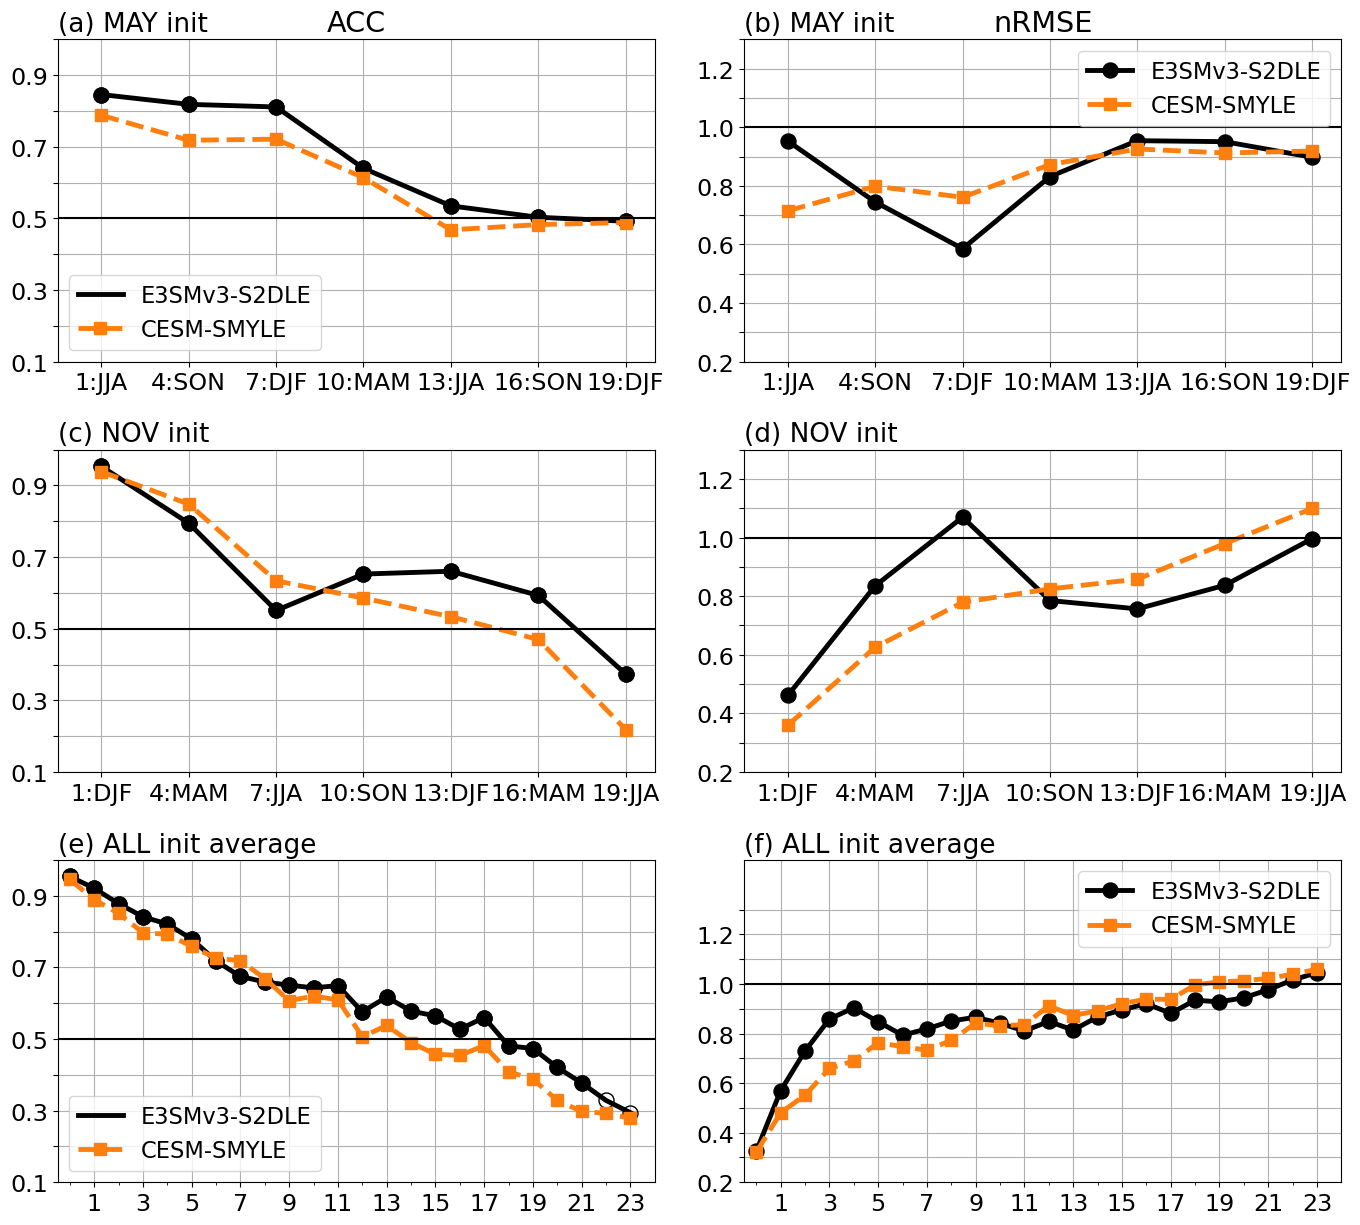

In [18]:
# -----------------------------
# Plot skill scores
# -----------------------------
# -----------------------------
# Plot setup: change values here to tune the figure
# -----------------------------
field = "nino3.4"
figfmt = "png"
period = f"{years}-{yeare}"
figname = figure_filename(field, "nino34_acc_skill", ext=figfmt)
dpi = 300
save_bbox = "tight"

startmonths_requested = cfg.init_months
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
header_fontz = fontz * 1.15
tick_fontz = fontz * 0.95
legend_fontz = fontz * 0.90

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
marker_size = fontz * 0.6
e3sm_marker_size = marker_size
smyle_marker_size = marker_size * 0.75

e3sm_label = "E3SMv3-S2DLE"
smyle_label = "CESM-SMYLE"
e3sm_color = "k"
smyle_color = "tab:orange"
smyle_linestyle = "--"
e3sm_marker = "o"
smyle_marker = "s"
significance_pval = 0.1
open_marker_fillstyle = "none"
marker_only_linestyle = "none"

hindcast_label = {2: "FEB init", 5: "MAY init", 8: "AUG init", 11: "NOV init"}
all_init_label = "ALL init average"
figlab_fmt = "({})"

season_labels_by_month = {
    2:  ["MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF"],
    5:  ["JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM"],
    8:  ["SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA"],
    11: ["DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON"],
}

seasonal_xlim = [-0.5, 20]
monthly_xlim = [-0.5, 24]
acc_ylim = [0.1, 1.0]
seasonal_rmse_ylim = [0.2, 1.3]
monthly_rmse_ylim = [0.2, 1.5]
acc_hline = 0.5
rmse_hline = 1.0
hline_color = "black"
show_grid = True
acc_header = "ACC"
rmse_header = "nRMSE"
acc_yticks = np.arange(10) * 0.1 + 0.1
acc_yticklabels = ["0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", ""]
rmse_yticks = np.arange(12) * 0.1 + 0.2
rmse_yticklabels = ["0.2", "", "0.4", "", "0.6", "", "0.8", "", "1.0", "", "1.2", ""]
monthly_xticks = np.arange(12) * 2 + 1
monthly_xticks_minor = np.arange(12) * 2
legend_locs = {"acc": "lower left", "rmse": "upper right"}

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})

# -----------------------------
# Derived plot values
# -----------------------------
leadsea = e3smle_seas_skill.L - 2
_nlead_seas = leadsea.sizes["L"]
xsea = {
    month: labels[:_nlead_seas]
    for month, labels in season_labels_by_month.items()
}
startmonths = [
    m for m in startmonths_requested
    if m in e3smle_seas_skill.startmonth.values
]
nrow = len(startmonths) + 1
fig = plt.figure(figsize=(fig_width, row_height * nrow))
figlabs = [figlab_fmt.format(chr(97 + i)) for i in range(nrow * ncol)]

# -----------------------------
# Seasonal skill panels by initialization month
# -----------------------------
for j, sm in enumerate(startmonths):
    sm_int = int(sm)
    ax = fig.add_subplot(nrow, ncol, j * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, j * 2 + 2)

    label = hindcast_label.get(sm_int, f"{sm_int:02d} init")

    ax.set_title(figlabs[j * 2] + " " + label, loc="left", fontsize=title_fontz)
    ax2.set_title(figlabs[j * 2 + 1] + " " + label, loc="left", fontsize=title_fontz)

    if j == 0:
        ax.set_title(acc_header, loc="center", fontsize=header_fontz)
        ax2.set_title(rmse_header, loc="center", fontsize=header_fontz)

    tmp = e3smle_seas_skill.sel(startmonth=sm)

    ax.plot(tmp.L - 2, tmp.corr, color=e3sm_color, linewidth=line_width, label=e3sm_label)
    ax.plot(tmp.L - 2, tmp.corr, color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, fillstyle=open_marker_fillstyle, linestyle=marker_only_linestyle)
    ax.plot(tmp.L - 2, tmp.corr.where(tmp.pval < significance_pval), color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, linestyle=marker_only_linestyle)

    ax2.plot(tmp.L - 2, tmp.rmse, color=e3sm_color, linewidth=line_width, marker=e3sm_marker, markersize=e3sm_marker_size, label=e3sm_label)

    if "smyle_seas_skill_plot" in globals() and sm in smyle_seas_skill_plot.startmonth.values:
        tmp_smyle = smyle_seas_skill_plot.sel(startmonth=sm)
        ax.plot(
            tmp_smyle.L - 2,
            tmp_smyle.corr,
            color=smyle_color,
            linewidth=line_width,
            linestyle=smyle_linestyle,
            marker=smyle_marker,
            markersize=smyle_marker_size,
            label=smyle_label,
        )
        ax2.plot(
            tmp_smyle.L - 2,
            tmp_smyle.rmse,
            color=smyle_color,
            linewidth=line_width,
            linestyle=smyle_linestyle,
            marker=smyle_marker,
            markersize=smyle_marker_size,
            label=smyle_label,
        )

    xticklabs = [f"{int(leadsea[i].data)}:{xsea[sm_int][i]}" for i in range(_nlead_seas)]

    ax.set_xticks(leadsea)
    ax.set_xticklabels(xticklabs, fontsize=tick_fontz)
    ax.set_yticks(acc_yticks)
    ax.set_yticklabels(acc_yticklabels, fontsize=tick_fontz)
    ax.set_xlim(seasonal_xlim)
    ax.set_ylim(acc_ylim)
    ax.tick_params(axis="both", labelsize=tick_fontz)
    ax.grid(show_grid)
    ax.axhline(y=acc_hline, color=hline_color)

    ax2.set_xticks(leadsea)
    ax2.set_xticklabels(xticklabs, fontsize=tick_fontz)
    ax2.set_yticks(rmse_yticks)
    ax2.set_yticklabels(rmse_yticklabels, fontsize=tick_fontz)
    ax2.set_xlim(seasonal_xlim)
    ax2.set_ylim(seasonal_rmse_ylim)
    ax2.tick_params(axis="both", labelsize=tick_fontz)
    ax2.grid(show_grid)
    ax2.axhline(y=rmse_hline, color=hline_color)

    if j == 0:
        ax.legend(loc=legend_locs["acc"], fontsize=legend_fontz)
        ax2.legend(loc=legend_locs["rmse"], fontsize=legend_fontz)

# -----------------------------
# Monthly ALL-init average panels
# -----------------------------
bottom_row = len(startmonths)
ax = fig.add_subplot(nrow, ncol, bottom_row * 2 + 1)
ax2 = fig.add_subplot(nrow, ncol, bottom_row * 2 + 2)

ax.set_title(figlabs[bottom_row * 2] + " " + all_init_label, loc="left", fontsize=title_fontz)
ax2.set_title(figlabs[bottom_row * 2 + 1] + " " + all_init_label, loc="left", fontsize=title_fontz)

tmp = e3smle_skill.mean("startmonth")

ax.plot(tmp.L - 1, tmp.corr, color=e3sm_color, linewidth=line_width, label=e3sm_label)
ax.plot(tmp.L - 1, tmp.corr, color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, fillstyle=open_marker_fillstyle, linestyle=marker_only_linestyle)
ax.plot(tmp.L - 1, tmp.corr.where(tmp.pval < significance_pval), color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, linestyle=marker_only_linestyle)

ax2.plot(tmp.L - 1, tmp.rmse, color=e3sm_color, linewidth=line_width, marker=e3sm_marker, markersize=e3sm_marker_size, label=e3sm_label)

if "smyle_skill_plot" in globals():
    # Bottom panels are monthly ALL-init averages, so use monthly CESM-SMYLE skill.
    tmp_smyle = smyle_skill_plot.mean("startmonth")
    ax.plot(
        tmp_smyle.L - 1,
        tmp_smyle.corr,
        color=smyle_color,
        linewidth=line_width,
        linestyle=smyle_linestyle,
        marker=smyle_marker,
        markersize=smyle_marker_size,
        label=smyle_label,
    )
    ax2.plot(
        tmp_smyle.L - 1,
        tmp_smyle.rmse,
        color=smyle_color,
        linewidth=line_width,
        linestyle=smyle_linestyle,
        marker=smyle_marker,
        markersize=smyle_marker_size,
        label=smyle_label,
    )
    ax.legend(loc=legend_locs["acc"], fontsize=legend_fontz)
    ax2.legend(loc=legend_locs["rmse"], fontsize=legend_fontz)

ax.set_xticks(monthly_xticks)
ax.set_xticks(monthly_xticks_minor, minor=True)
ax.tick_params(axis="both", labelsize=tick_fontz)
ax.set_yticks(acc_yticks)
ax.set_yticklabels(acc_yticklabels, fontsize=tick_fontz)
ax.set_xlim(monthly_xlim)
ax.set_ylim(acc_ylim)
ax.grid(show_grid)
ax.axhline(y=acc_hline, color=hline_color)

ax2.set_xticks(monthly_xticks)
ax2.set_xticks(monthly_xticks_minor, minor=True)
ax2.tick_params(axis="both", labelsize=tick_fontz)
ax2.set_yticks(rmse_yticks)
ax2.set_yticklabels(rmse_yticklabels, fontsize=tick_fontz)
ax2.set_xlim(monthly_xlim)
ax2.set_ylim(monthly_rmse_ylim)
ax2.grid(show_grid)
ax2.axhline(y=rmse_hline, color=hline_color)

fig.tight_layout()
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="nino34_sst_skill",
    title=f"Niño-3.4 SST Skill: {field}",
    caption=f"Verification period: {period}",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()


In [19]:
# -----------------------------
# DJF observed anomaly series
# -----------------------------
print(obs_seas.time)

jan = obs_seas.time.dt.month == 1
obs_djf = obs_seas.where(jan).dropna("time")
obs_djf = obs_djf - obs_djf.sel(time=slice(str(climy0), str(climy1))).mean("time")

<xarray.DataArray 'time' (time: 1846)> Size: 15kB
array([cftime.DatetimeNoLeap(1869, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1869, 3, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1869, 4, 15, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2022, 9, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2022, 10, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2022, 11, 15, 0, 0, 0, 0, has_year_zero=True)],
      shape=(1846,), dtype=object)
Coordinates:
  * time     (time) object 15kB 1869-02-15 00:00:00 ... 2022-11-15 00:00:00


In [20]:
# -----------------------------
# Combine seasonal drift-corrected series
# (order follows cfg.init_months)
# -----------------------------
startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

e3smle_seas = xr.concat(
    [results_dd[m]["seas_dd"] for m in cfg.init_months],
    dim=startmonth
)

e3smle_seas_time = xr.concat(
    [results[m]["time_seas"] for m in cfg.init_months],
    dim=startmonth
)

e3smle_seas_skill_plot = xr.concat(
    [results_skill[m]["skill_seas"] for m in cfg.init_months],
    dim=startmonth
)

print(e3smle_seas)
print(e3smle_seas_time)
print(e3smle_seas_skill_plot)


<xarray.DataArray 'TS' (startmonth: 2, Y: 78, L: 8, M: 10)> Size: 100kB
array([[[[ 1.78887273,  0.98183245,  1.58266801, ...,  1.75685482,
           1.73213785,  1.13079308],
         [ 2.1134412 , -0.12422353,  1.9072849 , ...,  2.23293516,
           2.4103891 ,  0.9293722 ],
         [ 1.75089081, -0.09270704,  1.4675236 , ...,  1.0123004 ,
           1.61220655,  0.70729162],
         ...,
         [-0.30820905,  0.01784086, -0.21139189, ..., -0.12517167,
          -0.63652211,  1.74664126],
         [-0.58818052,  0.3052841 ,  0.08953932, ..., -0.88447231,
          -0.72140392,  1.98544824],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
             

/tmp/ipykernel_85770/75750370.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
  e3smle_seas = xr.concat(
/tmp/ipykernel_85770/75750370.py:12: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
  e3smle_seas_time = xr.concat(


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nino3_4_nino34_time_series.png


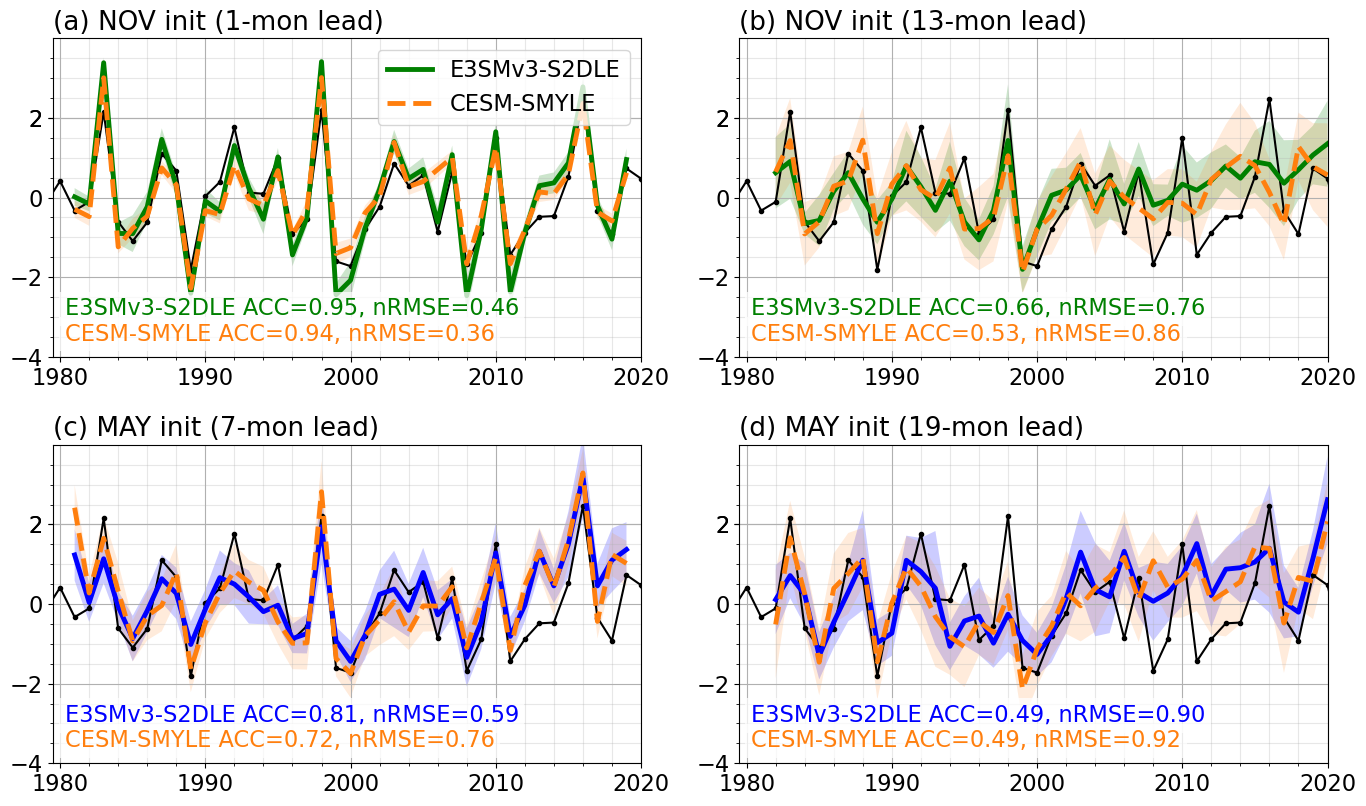

In [21]:
# -----------------------------
# Plot DJF Niño3.4 time series
# -----------------------------
# -----------------------------
# Plot setup: change values here to tune the figure
# -----------------------------
startmonths_requested = [11, 5]
djf_leads = {
    11: [3, 15],   # NOV init
    5: [9, 21],    # MAY init
}
startmonths_plot = [m for m in startmonths_requested if m in e3smle_seas.startmonth.values]
nrow = len(startmonths_plot)
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
tick_fontz = fontz * 0.9
legend_fontz = fontz * 0.9
annotation_fontz = fontz * 0.9

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
obs_marker_size = 6
e3sm_spread_alpha = 0.2
smyle_spread_alpha = 0.15
grid_minor_alpha = 0.3
annotation_box = dict(facecolor="white", alpha=0.75, edgecolor="none")
e3sm_annotation_xy = (0.02, 0.13)
smyle_annotation_xy = (0.02, 0.05)

plot_ylim = [-4.0, 4.0]
major_yticks = [-4, -2, 0, 2, 2]
minor_yticks = np.arange(-3.5, 4, 0.5)
plot_xmin = 1979.5
plot_xmax = 2020.0
major_years = [1980, 1990, 2000, 2010, 2020]
minor_years = np.arange(1980, 2021, 2)

hindcast_label = {11: "NOV", 5: "MAY"}
hindcast_color = {11: "g", 5: "b"}
e3sm_label = "E3SMv3-S2DLE"
smyle_color = "tab:orange"
obs_color = "k"
figlabs = [["(a)", "(c)"], ["(b)", "(d)"]]
field = "nino3.4"
figfmt = "png"
period = f"{years}-{yeare}"
figname = figure_filename(field, "nino34_time_series", ext=figfmt)
dpi = 300

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})
fig = plt.figure(figsize=(fig_width, row_height * nrow))

def _time_part_values(time_da, part, drop_missing=False):
    values = np.asarray(time_da.values).ravel()
    out = []

    for t in values:
        value = np.nan
        try:
            if t is not None:
                if hasattr(t, part):
                    value = getattr(t, part)
                else:
                    ts = pd.Timestamp(t)
                    if not pd.isna(ts):
                        value = getattr(ts, part)
        except (TypeError, ValueError, OverflowError):
            value = np.nan

        out.append(value)

    arr = np.asarray(out, dtype=float)
    if drop_missing:
        arr = arr[np.isfinite(arr)]
    return arr

def _year_values(time_da):
    return _time_part_values(time_da, "year")

if "M" in e3smle_seas.dims:
    member_dim = "M"
elif "member" in e3smle_seas.dims:
    member_dim = "member"
else:
    member_dim = None


for i, sm in enumerate(startmonths_plot):
    ax = fig.add_subplot(nrow, ncol, i * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, i * 2 + 2)

    for a in [ax, ax2]:
        a.set_ylim(plot_ylim)
        a.set_yticks(major_yticks)
        a.set_yticks(minor_yticks, minor=True)

        # x-axis like the reference figure
        a.set_xlim([plot_xmin, plot_xmax])
        a.set_xticks(major_years)
        a.set_xticks(minor_years, minor=True)
        a.tick_params(axis="both", labelsize=tick_fontz)

        a.plot(
            obs_djf.time.dt.year,
            obs_djf,
            color=obs_color,
            marker=".",
            markersize=obs_marker_size
        )

        a.grid(True, which="major")
        a.grid(True, which="minor", alpha=grid_minor_alpha)

    for col_idx, (ax_panel, target_L) in enumerate(zip([ax, ax2], djf_leads[sm])):

        available_L = e3smle_seas.sel(startmonth=sm).L.values
        if target_L not in available_L:
            ax_panel.set_title(f"L={target_L} not available", loc="left", fontsize=title_fontz)
            continue

        data = e3smle_seas.sel(startmonth=sm, L=target_L)
        tmp_time = e3smle_seas_time.sel(startmonth=sm, L=target_L)
        skill_row = e3smle_seas_skill_plot.sel(startmonth=sm, L=target_L)

        valid_months = _time_part_values(tmp_time, "month", drop_missing=True)
        if valid_months.size and not np.all(valid_months == 1):
            raise ValueError(
                f"Expected DJF center month January for startmonth={sm}, L={target_L}; "
                f"found months {np.unique(valid_months)}"
            )

        lead = int(target_L) - 2
        acc = float(skill_row.corr.values)
        nrmse = float(skill_row.rmse.values)

        datatime = _year_values(tmp_time)

        valid = np.isfinite(datatime)
        datatime_plot = datatime[valid]
        data_plot = data.isel(Y=valid)

        titl = f"{hindcast_label[sm]} init ({lead}-mon lead)"

        figlabel = figlabs[col_idx][i]
        ax_panel.set_title(figlabel + " " + titl, loc="left", fontsize=title_fontz)

        if member_dim is not None:
            datamean = data_plot.mean(member_dim)
            datastd = data_plot.std(member_dim)
        else:
            datamean = data_plot
            datastd = xr.zeros_like(data_plot)

        ax_panel.plot(
            datatime_plot,
            datamean,
            color=hindcast_color[sm],
            linewidth=line_width,
            label=e3sm_label,
        )

        ax_panel.fill_between(
            datatime_plot,
            (datamean - datastd).values,
            (datamean + datastd).values,
            fc=hindcast_color[sm],
            alpha=e3sm_spread_alpha,
        )

        ax_panel.text(
            *e3sm_annotation_xy,
            f"{e3sm_label} ACC={acc:3.2f}, nRMSE={nrmse:3.2f}",
            transform=ax_panel.transAxes,
            fontsize=annotation_fontz,
            color=hindcast_color[sm],
            bbox=annotation_box,
        )

        # Optional CESM-SMYLE overlay for the same initialization month and DJF lead.
        if (
            "smyle_seas" in globals()
            and "smyle_seas_time" in globals()
            and sm in smyle_seas.startmonth.values
            and target_L in smyle_seas.sel(startmonth=sm).L.values
        ):
            smyle_data = smyle_seas.sel(startmonth=sm, L=target_L)
            smyle_tmp_time = smyle_seas_time.sel(startmonth=sm, L=target_L)

            smyle_datatime = _year_values(smyle_tmp_time)
            smyle_valid = np.isfinite(smyle_datatime)

            smyle_datatime_plot = smyle_datatime[smyle_valid]
            smyle_data_plot = smyle_data.isel(Y=smyle_valid)

            if "M" in smyle_data_plot.dims:
                smyle_member_dim = "M"
            elif "member" in smyle_data_plot.dims:
                smyle_member_dim = "member"
            else:
                smyle_member_dim = None

            if smyle_member_dim is not None:
                smyle_mean = smyle_data_plot.mean(smyle_member_dim)
                smyle_std = smyle_data_plot.std(smyle_member_dim)
            else:
                smyle_mean = smyle_data_plot
                smyle_std = xr.zeros_like(smyle_data_plot)

            ax_panel.plot(
                smyle_datatime_plot,
                smyle_mean,
                color=smyle_color,
                linewidth=line_width,
                linestyle="--",
                label="CESM-SMYLE",
            )

            ax_panel.fill_between(
                smyle_datatime_plot,
                (smyle_mean - smyle_std).values,
                (smyle_mean + smyle_std).values,
                fc=smyle_color,
                alpha=smyle_spread_alpha,
            )

            if (
                "smyle_seas_skill_plot" in globals()
                and sm in smyle_seas_skill_plot.startmonth.values
                and target_L in smyle_seas_skill_plot.sel(startmonth=sm).L.values
            ):
                smyle_skill_row = smyle_seas_skill_plot.sel(startmonth=sm, L=target_L)
                smyle_acc = float(smyle_skill_row.corr.values)
                smyle_nrmse = float(smyle_skill_row.rmse.values)
                ax_panel.text(
                    *smyle_annotation_xy,
                    f"CESM-SMYLE ACC={smyle_acc:3.2f}, nRMSE={smyle_nrmse:3.2f}",
                    transform=ax_panel.transAxes,
                    fontsize=annotation_fontz,
                    color=smyle_color,
                    bbox=annotation_box,
                )

        if i == 0 and col_idx == 0:
            ax_panel.legend(loc="upper right", fontsize=legend_fontz)

fig.tight_layout()
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="nino34_sst_skill",
    title=f"Niño-3.4 SST Skill: {field}",
    caption=f"Verification period: {period}",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()

In [22]:
# -----------------------------
# Clean up Dask resources
# -----------------------------
close_cluster(cluster, client)